In [41]:
"""InverseSolver for DiffuserCam reconstruction — Lab 7 starter code.

Fill in the methods marked TODO to complete the lab.

Usage:
    from inverse_solver import InverseSolver, adjoint_test

    solver = InverseSolver(psf, algorithm='fista',
                           prox_fn=lambda x, l, s: np.maximum(x, 0))
    x_hat = solver(y)
    plt.plot(solver.losses)
"""

import numpy as np


class InverseSolver:
    """Reconstructs DiffuserCam images via iterative optimization.

    Parameters:
        psf: Point spread function array (H, W, C).
        algorithm: 'gradient_descent', 'ista', or 'fista'.
        prox_fn: Proximal operator with signature
            prox_fn(x, lam, step_size) -> x_new.
            If None, no proximal operator is applied.
        num_iters: Number of iterations to run.
        step_size: Step size for gradient updates. If None,
            estimated automatically via power iteration.
        lam: Regularization parameter (passed to prox_fn).
        mask: Optional binary mask (H, W, C) for compressive
            sensing. If None, all pixels are used.
    """

    def __init__(
        self,
        psf,
        algorithm="gradient_descent",
        prox_fn=None,
        num_iters=200,
        step_size=None,
        lam=0.0,
        mask=None,
    ):
        assert algorithm in ["gradient_descent", "ista", "fista"], (
            f"Unknown algorithm: {algorithm}"
        )

        # Normalize PSF and precompute frequency-domain arrays
        self.h = psf / np.linalg.norm(psf)
        self.H = np.fft.fft2(
            np.fft.ifftshift(self.pad(self.h), axes=(0, 1)), axes=(0, 1), norm="ortho"
        )
        self.H_conj = np.conj(self.H)

        # Store mask for compressive sensing (Lab 8)
        self.mask = mask

        # Compute step size
        if step_size is None:
            full_shape = (self.h.shape[0] * 2, self.h.shape[1] * 2, self.h.shape[2])
            L = self.power_iteration(full_shape)
            self.step_size = 1.0 / L
        else:
            self.step_size = step_size

        self.algorithm = algorithm
        self.prox_fn = prox_fn
        self.num_iters = num_iters
        self.lam = lam

    def __call__(self, y):
        """Run reconstruction on measurement y.

        Returns the estimated image, cropped to original size.
        Also stores self.losses (list of loss values per iteration).
        """
        x = np.zeros((y.shape[0] * 2, y.shape[1] * 2, y.shape[2]))
        v = np.zeros_like(x)  # momentum term (FISTA only)
        t = 1.0  # acceleration param (FISTA only)

        self.losses = []
        for i in range(self.num_iters):
            if self.algorithm == "gradient_descent":
                x, loss = self.gd_update(x, y)
            elif self.algorithm == "ista":
                x, loss = self.ista_update(x, y)
            elif self.algorithm == "fista":
                v, t, x, loss = self.fista_update(v, t, x, y)
            self.losses.append(loss)
        return self.crop(x)

    # ----------------------------------------------------------------
    # Provided helper methods
    # ----------------------------------------------------------------

    def pad(self, img):
        """Zero-pad image to 2x size. (H,W,C) -> (2H,2W,C)"""
        return np.pad(
            img,
            (
                (img.shape[0] // 2, img.shape[0] // 2),
                (img.shape[1] // 2, img.shape[1] // 2),
                (0, 0),
            ),
            mode="constant",
        )

    def crop(self, img):
        """Crop padded image back to original size.
        (2H,2W,C) -> (H,W,C)"""
        return img[
            img.shape[0] // 4 : -img.shape[0] // 4,
            img.shape[1] // 4 : -img.shape[1] // 4,
        ]

    def prox(self, x):
        """Apply the proximal operator if one was provided."""
        if self.prox_fn is None:
            return x
        return self.prox_fn(x, self.lam, self.step_size)

    # ----------------------------------------------------------------
    # TODO: Implement the methods below
    # ----------------------------------------------------------------

    def A(self, x):
        """Forward model: A(x) = crop(IFFT(H * FFT(x))).

        Steps:
            1. Compute FFT of x (axes 0,1, norm='ortho')
            2. Multiply by self.H in frequency domain
            3. Compute IFFT (axes 0,1, norm='ortho'), take real part
            4. Crop to measurement size using self.crop()
            5. If self.mask is not None, multiply by self.mask

        Args:
            x: Image in padded space (2H, 2W, C)
        Returns:
            Measurement-space result (H, W, C)
        """
        X = np.fft.fft2(x, axes=(0, 1), norm="ortho")
        out = np.real(self.crop(np.fft.ifft2(X * self.H, axes=(0, 1), norm="ortho")))
        if self.mask is not None:
            out = out * self.mask
        return out

    def A_adjoint(self, y):
        """Adjoint: A*(y) = IFFT(conj(H) * FFT(pad(y))).

        Steps:
            1. If self.mask is not None, multiply y by self.mask
            2. Zero-pad y using self.pad()
            3. Compute FFT of padded y (axes 0,1, norm='ortho')
            4. Multiply by self.H_conj in frequency domain
            5. Compute IFFT (axes 0,1, norm='ortho'), take real part

        Args:
            y: Measurement-space input (H, W, C)
        Returns:
            Image-space result (2H, 2W, C)
        """
        if self.mask is not None:
            y = y * self.mask
        Y = np.fft.fft2(self.pad(y), axes=(0, 1), norm="ortho")
        return np.real(np.fft.ifft2(Y * self.H_conj, axes=(0, 1), norm="ortho"))

    def power_iteration(self, full_shape, num_iters=10):
        """Estimate largest eigenvalue of A*A via power iteration.

        Do NOT include crop/pad — work in the full padded space.
        Repeatedly apply H in frequency domain to a random vector:
            b_{k+1} = real(IFFT(H * FFT(b_k)))
            b_{k+1} = b_{k+1} / ||b_{k+1}||

        After num_iters, estimate the eigenvalue via the Rayleigh
        quotient: eigenvalue = (b^T M b) / (b^T b)
        where M b = real(IFFT(H * FFT(b))).

        Args:
            full_shape: (2H, 2W, C) shape of padded space
            num_iters: Number of iterations (default 10)
        Returns:
            Estimated largest eigenvalue (float)
        """
        bk = np.random.randn(*full_shape).astype(np.float32)
        for _ in range(num_iters):
            X = np.fft.fft2(bk, axes=(0, 1), norm="ortho")
            bk1 = np.real(np.fft.ifft2(X * self.H, axes=(0, 1), norm="ortho"))
            bk = bk1 / np.linalg.norm(bk1)
        X = np.fft.fft2(bk, axes=(0, 1), norm="ortho")
        Mbk = np.real(np.fft.ifft2(X * self.H, axes=(0, 1), norm="ortho"))
        eigenvalue = np.dot(bk.ravel(), Mbk.ravel()) / np.dot(bk.ravel(), bk.ravel())
        return eigenvalue

    def gd_update(self, x, y):
        """One gradient descent step.

        x_new = x - step_size * A_adjoint(A(x) - y)

        Args:
            x: Current estimate (2H, 2W, C)
            y: Measurement (H, W, C)
        Returns:
            (x_new, loss) where loss = self.loss(error)
        """
        error = self.A(x) - y
        x = x - (self.step_size * self.A_adjoint(error))
        return x, self.loss(error)

    def loss(self, error):
        """Compute the data fidelity loss.

        loss = 0.5 * ||error||_2^2

        Args:
            error: Residual A(x) - y
        Returns:
            Scalar loss value (float)
        """
        return 0.5 * np.linalg.norm(error)**2


def adjoint_test(solver, y_shape):
    """Verify that A and A_adjoint satisfy <y, Ax> == <A*y, x>.

    Creates random x (in padded space) and y (in measurement space),
    then checks that the two inner products are equal.

    Args:
        solver: An InverseSolver instance (with A and A_adjoint
            implemented)
        y_shape: Shape of measurement, e.g. (H, W, C)
    Returns:
        (lhs, rhs) tuple — these should be nearly equal
    """
    full_shape = (y_shape[0] * 2, y_shape[1] * 2, y_shape[2])
    x = np.random.randn(*full_shape)
    y = np.random.randn(*y_shape)

    Ax = solver.A(x)
    As_y = solver.A_adjoint(y)

    lhs = np.dot(y.ravel(), Ax.ravel())
    rhs = np.dot(As_y.ravel(), x.ravel())
    return lhs, rhs


In [9]:
solver = InverseSolver(psf=np.random.rand(10, 10, 3), step_size=0.1) 
y_shape = (10, 10, 3)
l, r = adjoint_test(solver, y_shape)
print(f"Adjoint test: <y, Ax> = {l:.4f}, <A*y, x> = {r:.4f}")


Adjoint test: <y, Ax> = 0.5969, <A*y, x> = 0.5969


In [10]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


c:\Users\gmone\miniconda3\envs\cs4660\Lib\site-packages\numpy\linalg\_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


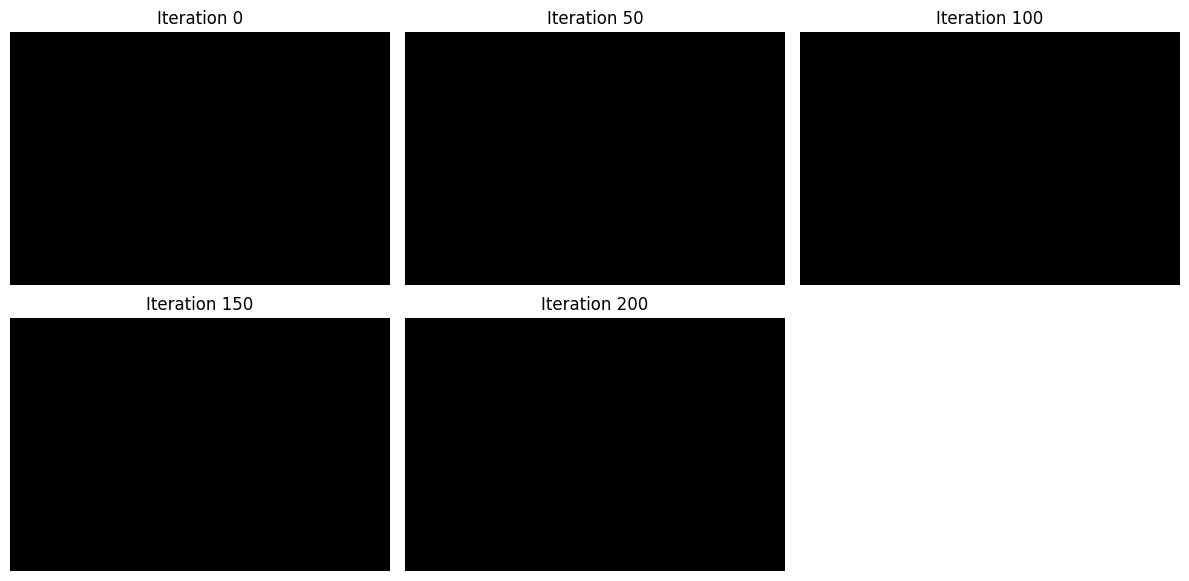

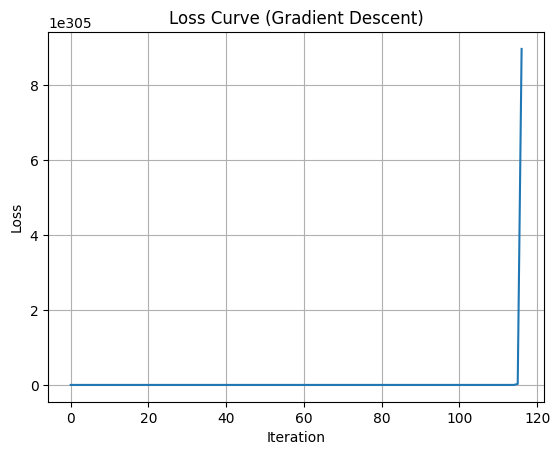

In [ ]:
import matplotlib.pyplot as plt

psf = (plt.imread('img/IMG_0154.jpg').astype(np.float64)) / 255.0
dif = (plt.imread('img/IMG_0155.jpg').astype(np.float64)) / 255.0
reference = (plt.imread('img/IMG_0156.jpg').astype(np.float64)) / 255.0

psf = psf[::10, ::10, :]
y = dif[::10, ::10, :]

solver = InverseSolver(
    psf,
    algorithm="gradient_descent",
    num_iters=200,
    step_size=1000
)

x = np.zeros((y.shape[0] * 2, y.shape[1] * 2, y.shape[2]))
recons = {}
losses = []

checkpoints = [0, 50, 100, 150, 200]

for i in range(201): 
    if i > 0:
        x, loss = solver.gd_update(x, y)
        losses.append(loss)

    if i in checkpoints:
        recons[i] = solver.crop(x)

plt.figure(figsize=(12, 6))
for idx, it in enumerate(checkpoints):
    plt.subplot(2, 3, idx + 1)
    plt.imshow(np.clip(recons[it], 0, 1))
    plt.title(f"Iteration {it}")
    plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure()
plt.plot(losses)
plt.title("Loss Curve (Gradient Descent)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

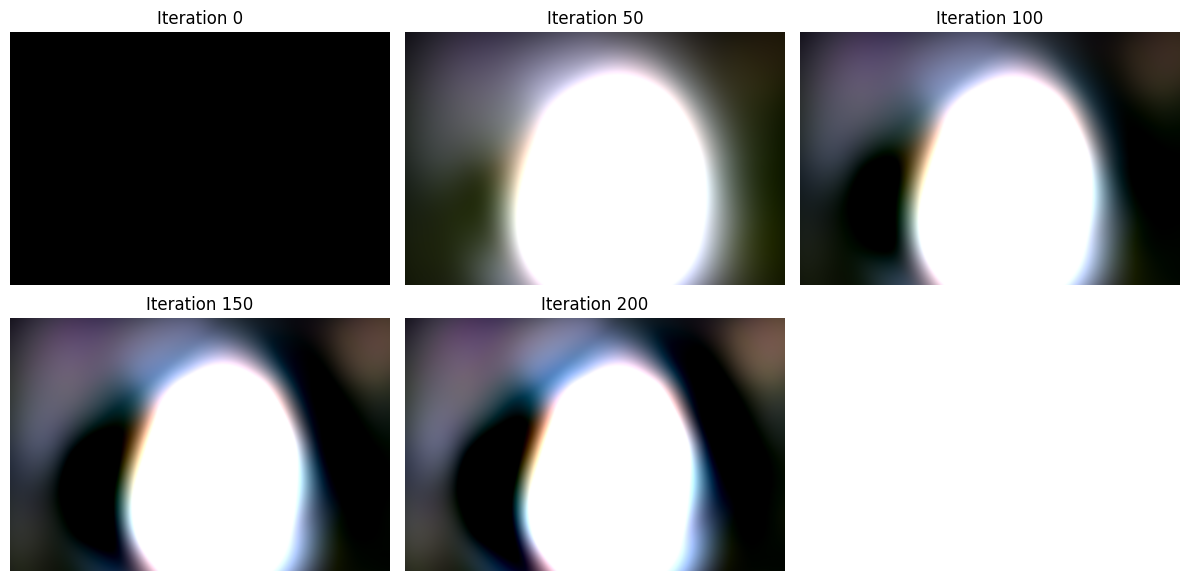

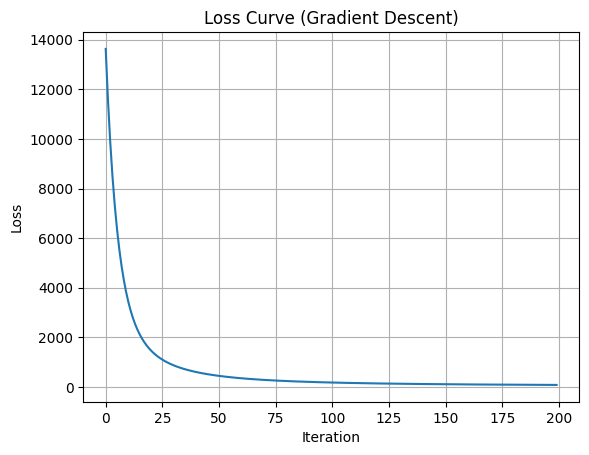

In [42]:
psf = (plt.imread('img/IMG_0154.jpg').astype(np.float64)) / 255.0
dif = (plt.imread('img/IMG_0155.jpg').astype(np.float64)) / 255.0
reference = (plt.imread('img/IMG_0156.jpg').astype(np.float64)) / 255.0

psf = psf[::10, ::10, :]
y = dif[::10, ::10, :]
psf = psf / np.sum(psf)
y = y - np.min(y)


solver = InverseSolver(
    psf,
    algorithm="gradient_descent",
    num_iters=200,
)

x = np.zeros((y.shape[0] * 2, y.shape[1] * 2, y.shape[2]))
recons = {}
losses = []

checkpoints = [0, 50, 100, 150, 200]

for i in range(201):
    if i > 0:
        x, loss = solver.gd_update(x, y)
        losses.append(loss)

    if i in checkpoints:
        recons[i] = solver.crop(x)

plt.figure(figsize=(12, 6))
for idx, it in enumerate(checkpoints):
    plt.subplot(2, 3, idx + 1)
    plt.imshow(np.clip(recons[it], 0, 1))
    plt.title(f"Iteration {it}")
    plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure()
plt.plot(losses)
plt.title("Loss Curve (Gradient Descent)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [18]:
%pip install torch

   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   -- ------------------------------------- 5.8/114.6 MB 32.0 MB/s eta 0:00:04
   ---- ----------------------------------- 12.3/114.6 MB 32.2 MB/s eta 0:00:04
   ------ --------------------------------- 18.9/114.6 MB 33.1 MB/s eta 0:00:03
   ------- -------------------------------- 22.3/114.6 MB 32.8 MB/s eta 0:00:03
   ------- -------------------------------- 22.3/114.6 MB 32.8 MB/s eta 0:00:03
   --------- ------------------------------ 27.0/114.6 MB 22.8 MB/s eta 0:00:04
   ----------- ---------------------------- 34.1/114.6 MB 24.6 MB/s eta 0:00:04
   ------------- -------------------------- 39.8/114.6 MB 25.1 MB/s eta 0:00:03
   ---------------- ----------------------- 46.7/114.6 MB 26.0 MB/s eta 0:00:03
   ------------------ --------------------- 53.7/114.6 MB 26.9 MB/s eta 0:00:03
   --------------------- ------------------ 60.8/114.6 MB 27.7 MB/s eta 0:00:02
   ----------------------- ---------------- 67.9/1

Part 3

In [76]:
import torch
import numpy as np
import matplotlib.pyplot as plt 

solver = InverseSolver(psf = psf, )

# input the y in
psf = (plt.imread('img/IMG_0154.jpg').astype(np.float64)) / 255.0
dif = (plt.imread('img/IMG_0155.jpg').astype(np.float64)) / 255.0
reference = (plt.imread('img/IMG_0156.jpg').astype(np.float64)) / 255.0

psf = psf[::10, ::10, :]
y = dif[::10, ::10, :]

# Convert H to a PyTorch tensor.
# H is complex-valued, so we use complex128.
H_torch = torch.tensor(solver.H, dtype=torch.complex128)
# Convert measurement y to a PyTorch tensor.
y_torch = torch.tensor(y, dtype=torch.float64)
# Create image estimate x as zeros.
# requires_grad=True tells PyTorch to track all
# operations on x so it can compute gradients.
full_shape = (y.shape[0]*2, y.shape[1]*2, y.shape[2])
x = torch.zeros(full_shape, dtype=torch.float64, requires_grad=True)

In [78]:
def forward_torch(x, H_torch):
    """DiffuserCam forward model in PyTorch."""
    X = torch.fft.fft2(x, dim=(0,1), norm="ortho")
    out = torch.fft.ifft2(X * H_torch, dim=(0,1), norm="ortho").real
    # crop
    h4 = out.shape[0] // 4
    w4 = out.shape[1] // 4
    return out[h4:-h4, w4:-w4]

In [79]:
y_hat = forward_torch(x, H_torch)
loss = 0.5 * torch.sum((y_hat - y_torch)**2)
loss.backward() # computes gradients

print(x.grad.shape) # same shape as x
grad_torch = x.grad.numpy()
x_new = x.detach().numpy()
grad_numpy = solver.A_adjoint(solver.A(x_new)-y)
max_diff = np.max(np.abs(grad_torch - grad_numpy))
print(max_diff)

torch.Size([800, 1200, 3])
4.163336342344337e-17


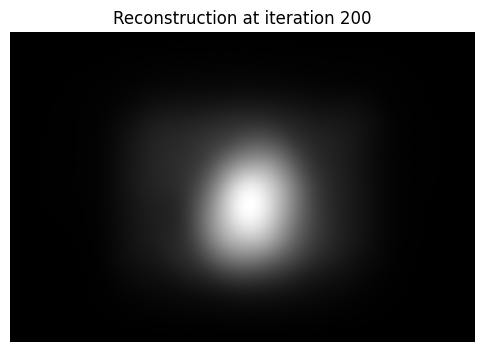

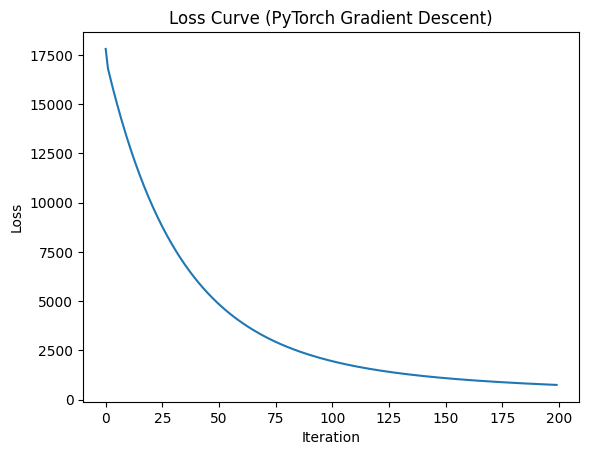

In [80]:
losses = []
num_iters = 200
step_size = 1
listy = {} 
for i in range(num_iters):
    # Forward pass
    y_hat = forward_torch(x, H_torch)
    loss = 0.5 * torch.sum((y_hat - y_torch)**2)
    # Backward pass: compute gradients
    loss.backward()
    # Update x (don’t track this operation)
    with torch.no_grad():
        x.data -= step_size * x.grad
        x.grad.zero_() # clear for next iteration
    losses.append(loss.item()) # .item() -> float
    x_hat = x.detach().numpy()
    if i in [0, 50, 100, 150, 200-1]:
        listy[i] = x_hat 
        
plt.figure(figsize=(6,6))
plt.imshow(listy[199][:,:,0], cmap='gray') 
plt.title("Reconstruction at iteration 200")
plt.axis('off')
plt.show()

# Plot the loss curve
plt.figure()
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss Curve (PyTorch Gradient Descent)")
plt.show()